# 02c · Fine-tuning YOLOv8s + CBAM

**Alur:** fine-tuning (transfer learning dari bobot COCO) → evaluasi split uji.

Model: **cbam**. Dilatih **multi-seed** `[42, 0, 1]` untuk estimasi variansi
(rata-rata ± std dilaporkan di notebook **03**).

> ⚠️ **Eksekusi sekuensial & mandiri.** Tiap seed dilatih satu per satu (TIDAK paralel),
> dan `clear_gpu()` dipanggil di antara run agar tidak ada memori GPU sisa (redundant).

In [ ]:
# === Setup: lingkungan, seed, util (pure-notebook: self-contained, tanpa src/) ===
from __future__ import annotations
import os, gc, json, random, sys, platform
from pathlib import Path

import numpy as np
import torch
import yaml

# Lokasi repo: telusuri ke atas dari cwd sampai menemukan requirements.txt
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "requirements.txt").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_YAML = REPO_ROOT / "data" / "helmet-roboflow" / "data.yaml"
TEST_IMG_DIR = REPO_ROOT / "data" / "helmet-roboflow" / "test" / "images"
TEST_LBL_DIR = REPO_ROOT / "data" / "helmet-roboflow" / "test" / "labels"
EXP = REPO_ROOT / "experiments"
FIG = REPO_ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
CLASS_NAMES = ["helmet", "license_plate", "motorcyclist"]


def set_seed(seed: int = 42, deterministic: bool = True) -> int:
    """Patok seed untuk random/numpy/torch (reproducibility)."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    return seed


def clear_gpu() -> None:
    """Bersihkan cache GPU antar-run agar tak ada memori sisa (hindari redundant)."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def collect_env() -> dict:
    info = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "cuda_available": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    try:
        import ultralytics
        info["ultralytics"] = ultralytics.__version__
    except ImportError:
        info["ultralytics"] = None
    return info


def save_metrics(metrics: dict, run_dir: Path) -> dict:
    """Tulis metrik ke metrics.json + metrics.csv di folder run (satu sumber kebenaran)."""
    import pandas as pd
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))
    pd.DataFrame([metrics]).to_csv(run_dir / "metrics.csv", index=False)
    return metrics


print("REPO_ROOT :", REPO_ROOT)
print("ENV       :", json.dumps(collect_env(), indent=2))
assert DATA_YAML.exists(), f"data.yaml tidak ditemukan: {DATA_YAML}"


## Konfigurasi

In [ ]:
# === Konfigurasi fine-tuning (inline — pure-notebook, bukan dari configs/) ===
ARCH = "cbam"
SEEDS = [42, 0, 1]
TRAIN = dict(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=1280,        # objek helmet/plate kecil -> resolusi tinggi
    batch=-1,          # auto-batch (maksimalkan VRAM RTX 4090)
    optimizer="auto",
    lr0=0.01,
    patience=25,       # early stopping
    device=0,          # GPU tunggal; fine-tuning TIDAK paralel
    # augmentasi (dilaporkan saat membandingkan)
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, fliplr=0.5, mosaic=1.0, scale=0.5,
)
# CBAM perlu terdaftar di parser Ultralytics sebelum membangun arsitektur dari YAML.
import ultralytics.nn.tasks as _tasks
from ultralytics.nn.modules import CBAM as _CBAM
_tasks.CBAM = _CBAM
CBAM_YAML = str(REPO_ROOT / "configs" / "yolov8s_cbam.yaml")

## Training multi-seed (sekuensial)

In [ ]:
# === Loop training multi-seed: SEKUENSIAL + clear cache GPU antar-run ===
from ultralytics import YOLO

summary = []
for seed in SEEDS:
    set_seed(seed)
    run_name = f"ft_{ARCH}_seed{seed}"
    print(f"\n{'='*60}\n  TRAIN {run_name}  (seed={seed})\n{'='*60}")

    model = YOLO(CBAM_YAML).load(str(EXP / "yolov8s.pt"))
    model.train(**TRAIN, seed=seed, deterministic=True,
                project=str(EXP), name=run_name, exist_ok=True)

    # Evaluasi di split TEST (hindari leakage; split tetap)
    m = model.val(data=str(DATA_YAML), imgsz=TRAIN["imgsz"], batch=16,
                  split="test", device=0)
    out = {"mAP50": float(m.box.map50), "mAP50_95": float(m.box.map),
           "precision": float(m.box.mp), "recall": float(m.box.mr)}
    spd = getattr(m, "speed", None)
    if spd and spd.get("inference"):
        out["fps"] = 1000.0 / spd["inference"]
    save_metrics(out, EXP / run_name)
    summary.append({"seed": seed, **out})
    print(f"  -> {run_name}: mAP50={out['mAP50']:.4f}  mAP50_95={out['mAP50_95']:.4f}")

    # Bersihkan SEBELUM seed berikutnya (mandiri, tanpa memori sisa)
    del model
    clear_gpu()

print("\nSelesai semua seed.")

## Ringkasan

In [ ]:
# === Ringkasan multi-seed untuk cbam ===
import pandas as pd
import statistics as stats

sdf = pd.DataFrame(summary)
display(sdf.style.format({c: "{:.4f}" for c in sdf.columns if c != "seed"}))
m50 = sdf["mAP50"].tolist()
print(f"mAP@0.5     : {stats.mean(m50):.4f} ± {stats.stdev(m50) if len(m50)>1 else 0:.4f} (n={len(m50)})")
m5095 = sdf["mAP50_95"].tolist()
print(f"mAP@[.5:.95]: {stats.mean(m5095):.4f} ± {stats.stdev(m5095) if len(m5095)>1 else 0:.4f}")

## Inferensi kualitatif (tanpa retraining)

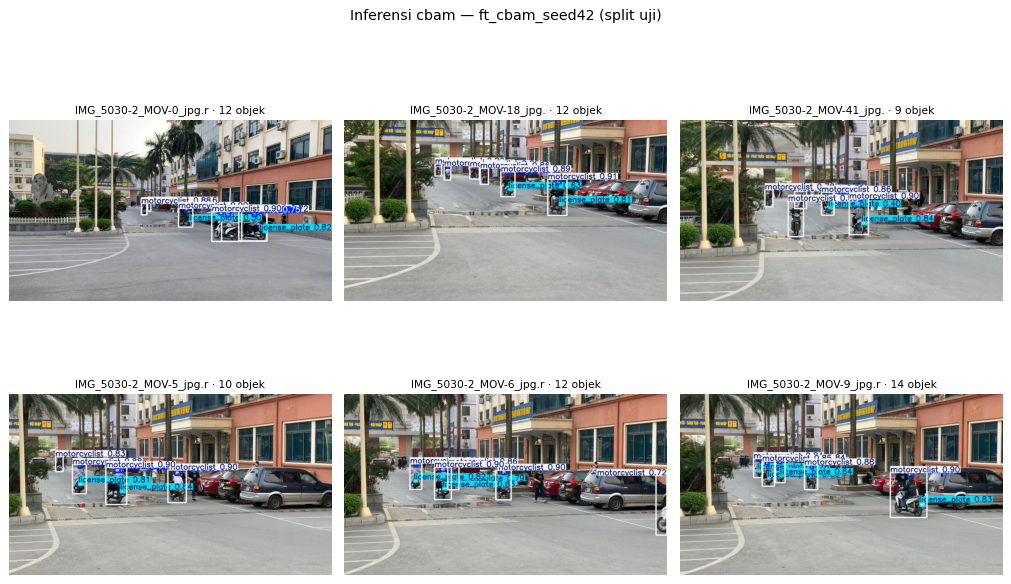

In [ ]:
# === Inferensi kualitatif (TANPA retraining \u2014 muat checkpoint terlatih) ===
%matplotlib inline
import matplotlib.pyplot as plt
from ultralytics import YOLO

INFER_RUN = f"ft_{ARCH}_seed42"          # run seed 42 (checkpoint sudah ada)
CKPT = EXP / INFER_RUN / "weights" / "best.pt"
assert CKPT.exists(), f"Checkpoint tak ada: {CKPT} \u2014 jalankan sel training dulu."

model = YOLO(str(CKPT))
samples = sorted(p for p in TEST_IMG_DIR.iterdir()
                 if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"})[:6]
res = model.predict([str(p) for p in samples], imgsz=1280, conf=0.25, verbose=False, device=0)

cols = 3; rows = (len(res) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), dpi=85); axes = axes.ravel()
for ax, r, p in zip(axes, res, samples):
    ax.imshow(r.plot()[:, :, ::-1])      # BGR -> RGB
    ax.set_title(f"{p.name[:22]} \u00b7 {len(r.boxes)} objek", fontsize=9); ax.axis("off")
for ax in axes[len(res):]:
    ax.axis("off")
plt.suptitle(f"Inferensi {ARCH} \u2014 {INFER_RUN} (split uji)", fontsize=12)
plt.tight_layout(); plt.savefig(FIG / f"infer_{ARCH}.png", dpi=100); plt.show()
del model; clear_gpu()
